In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import Packages
from Input_Output_Rxn_Networks.IOCRN_MassAction import IOCRN_MassAction
from Input_Output_Rxn_Networks.ParameterSequenceGenerator import ParameterSequenceGenerator
from Input_Output_Rxn_Networks.ParameterSequenceGenerator import map_index_to_parameter
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
# Construct an IOCRN modeling a Gene Expression process
stoichiometry_reactants = np.array([[1, 0, 1, 0], [0, 1, 0, 0]], dtype=np.int8)
stoichiometry_products = np.array([[0, 0, 1, 1], [0, 0, 1, 0]], dtype=np.int8)
gamma_1 = 2; gamma_2 = 2; k = 4
true_parameters = np.array([gamma_1, gamma_2, k, 1], dtype=np.float32)
input_influence_matrix = np.array([[0, 0, 0, 1]], dtype=np.int8)
outputs = np.array([2], dtype=np.int8)
IOCRN_true = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, true_parameters, input_influence_matrix, outputs)
species = ['X_1', 'X_2']
inputs = ['u']
IOCRN_true.print_reactions(species, inputs)

Inputs: ['u']
Species: ['X_1', 'X_2']
Output Species: ['X_2']
Reaction 1: X_1 -> 0 ; Rate Constant: 2.0
Reaction 2: X_2 -> 0 ; Rate Constant: 2.0
Reaction 3: X_1 -> X_1 + X_2 ; Rate Constant: 4.0
Reaction 4: 0 -> X_1 ; Rate Constant: 1.0u


In [4]:
# Construct the parameter grid
N_grid = 10
N_parameters = 3
theta_1 = np.linspace(1, 5, N_grid, dtype=np.float32)
theta_2 = np.linspace(1, 5, N_grid, dtype=np.float32)
theta_3 = np.linspace(1, 25, N_grid, dtype=np.float32)
parameter_grid = np.stack([theta_1, theta_2, theta_3], axis=0)
print(parameter_grid)

[[ 1.         1.4444444  1.8888888  2.3333333  2.7777777  3.2222223
   3.6666667  4.111111   4.5555553  5.       ]
 [ 1.         1.4444444  1.8888888  2.3333333  2.7777777  3.2222223
   3.6666667  4.111111   4.5555553  5.       ]
 [ 1.         3.6666667  6.3333335  9.        11.666667  14.333333
  17.        19.666666  22.333334  25.       ]]


In [5]:
# Construct the Parameter Sequence Generator
N_samples = 4
MyIOCRN = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, [], input_influence_matrix, outputs)
MyPSG = ParameterSequenceGenerator(MyIOCRN, parameter_grid, LSTM_hidden_size=128, FFNN_hidden_size=128, FFNN_num_layers=5, num_samples=N_samples)

In [6]:
# Map Indices to Parameters
indices = torch.randint(0, N_grid, size=(N_samples, N_parameters)).int()
parameters = map_index_to_parameter(indices, parameter_grid)
print(indices.shape)
print(parameters.shape)

torch.Size([4, 3])
(3, 4)


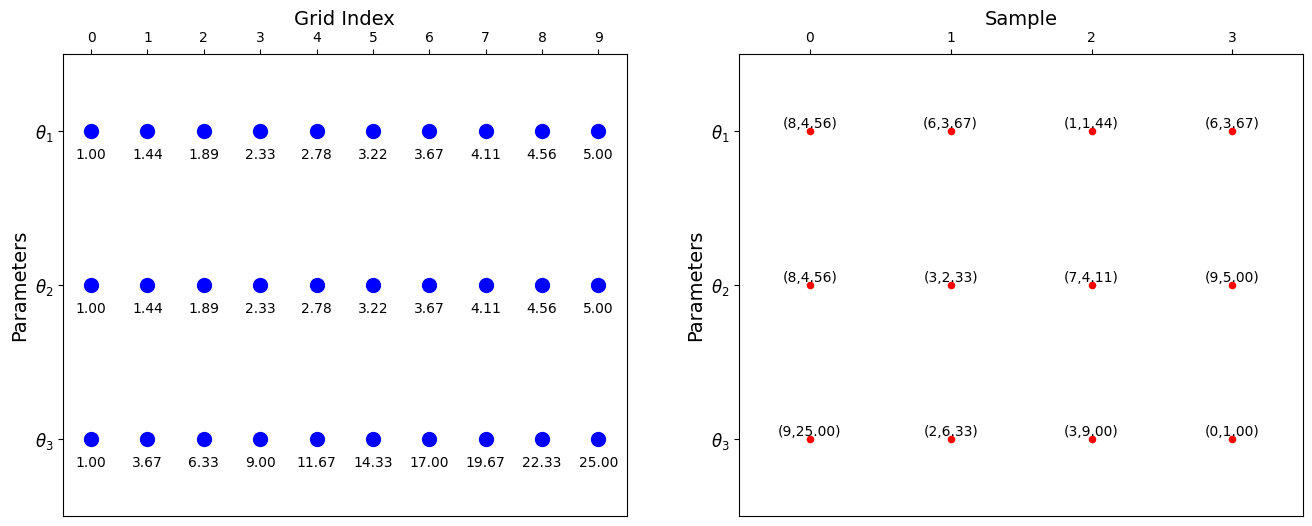

In [7]:
# Plot the results
# First Axis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_ticks = np.arange(N_grid)  
axes[0].set_xticks(x_ticks.tolist())
axes[0].set_xticklabels([f"{i.item()}" for i in x_ticks])
axes[0].xaxis.set_label_position('top')  
axes[0].xaxis.tick_top() 
y_ticks = np.arange(N_parameters) 
y_labels = [rf"$\theta_{{{i+1}}}$" for i in y_ticks.tolist()]
axes[0].set_yticks(y_ticks.tolist())  
axes[0].set_yticklabels(y_labels, fontsize=12)

for i in range(N_parameters):
    for j in range(N_grid):
        value = parameter_grid[i, j].item()
        axes[0].scatter(j, i, s=100, color='blue', alpha=1) 
        axes[0].text(j, i + 0.2, f"{value:.2f}", fontsize=10, ha='center', va='bottom')

axes[0].set_xlim(-0.5, N_grid - 0.5)
axes[0].set_ylim(-0.5, N_parameters - 0.5)
axes[0].invert_yaxis() 
axes[0].set_xlabel("Grid Index", fontsize=14)
axes[0].set_ylabel("Parameters", fontsize=14)
axes[0].grid(False)

# Second Axis
x_ticks = np.arange(N_samples)  
axes[1].set_xticks(x_ticks.tolist())
axes[1].set_xticklabels([f"{i.item()}" for i in x_ticks])
axes[1].xaxis.set_label_position('top')  
axes[1].xaxis.tick_top() 
y_ticks = np.arange(N_parameters) 
y_labels = [rf"$\theta_{{{i+1}}}$" for i in y_ticks.tolist()]
axes[1].set_yticks(y_ticks.tolist())  
axes[1].set_yticklabels(y_labels, fontsize=12)

for i in range(N_samples):
    for j in range(N_parameters):
        value = parameters[j, i].item()
        index = indices[i, j].item()
        axes[1].scatter(i, j, s=20, color='red', alpha=1)
        axes[1].text(i,j, f"({index},{value:.2f})", fontsize=10, ha='center', va='bottom')

axes[1].set_xlim(-0.5, N_samples - 0.5)
axes[1].set_ylim(-0.5, N_parameters - 0.5)
axes[1].invert_yaxis() 
axes[1].set_xlabel("Sample", fontsize=14)
axes[1].set_ylabel("Parameters", fontsize=14)
axes[1].grid(False)

plt.show()
